In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
from astropy.io import fits
from matplotlib import pyplot as plt

#from pipeline_config import MAPS_DIR

In [2]:
datasets = [
    {
        "instrument": "MUSE",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin0.fits",
        "label": r"H$\alpha$",
    },
        {
        "instrument": "MUSE trim",
        "line": "Halpha",
        "filename": "MUSE-M42-H-bin0_trim.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "MUSE",
        "line": "NII_6583",
        "filename": "MUSE-M42-N-bin0.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "MUSE",
        "line": "OIII_5007",
        "filename": "MUSE-M42-O-bin0.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "MUSE",
        "line": "SIII_9069",
        "filename": "MUSE-M42-S-bin0.fits",
        "label": r"[S III] $\lambda$9069",
    },
    {
        "instrument": "MUSE",
        "line": "ArIII_7136",
        "filename": "MUSE-M42-Ar-bin0.fits",
        "label": r"[Ar III] $\lambda$7136",
    },

    {
        "instrument": "KPNO",
        "line": "Halpha",
        "filename": "KPNO-M42-H-bin0.fits",
        "label": r"H$\alpha$",
    },
    {
        "instrument": "KPNO",
        "line": "NII_6583",
        "filename": "KPNO-M42-N-bin0.fits",
        "label": r"[N II] $\lambda$6583",
    },
    {
        "instrument": "KPNO",
        "line": "OIII_5007",
        "filename": "KPNO-M42-O-bin0.fits",
        "label": r"[O III] $\lambda$5007",
    },
    {
        "instrument": "KPNO",
        "line": "SII_6731",
        "filename": "KPNO-M42-S-bin0.fits",
        "label": r"[S II] $\lambda$6731",
    },
]

In [3]:
def load_velocity_dataset(entry):
    fits_path = entry["filename"]

    with fits.open(fits_path) as hdul:
        sb = hdul["MOM0"].data.astype(float)
        vv = hdul["MOM1"].data.astype(float)
        mask = hdul["MASK"].data.astype(bool)

    sb = np.where(mask, sb, np.nan)
    vv = np.where(mask, vv, np.nan)

    df = pd.DataFrame({
        "X": np.indices(vv.shape)[0].ravel(),
        "Y": np.indices(vv.shape)[1].ravel(),
        "VV": vv.ravel(),
        "SB": sb.ravel(),
        "mask": mask.ravel(),
    })

    df = df.dropna(subset=["VV"])

    df["instrument"] = entry["instrument"]
    df["line"] = entry["line"]
    df["label"] = entry["label"]
    df["filename"] = entry["filename"]

    mean_v = df["VV"].mean()
    df["RV_centered"] = df["VV"] - mean_v

    raw = {
        "sb": sb,
        "vv": vv,
        "mask": mask,
        "instrument": entry["instrument"],
        "line": entry["line"],
        "label": entry["label"],
        "filename": entry["filename"],
    }

    return df, raw

In [4]:
processed_list = []
raw_data = {}

for entry in datasets:
    df, raw = load_velocity_dataset(entry)
    processed_list.append(df)

    key = (entry["line"], entry["instrument"])
    raw_data[key] = raw

processed_data = pd.concat(processed_list, ignore_index=True)

In [5]:
processed_data.head()

,X,Y,VV,SB,mask,instrument,line,label,filename,RV_centered
0,0,586,15.751118,0.032778,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,1.896868
1,0,587,11.852624,0.031848,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-2.001627
2,0,588,13.774124,0.031479,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-0.080127
3,0,589,13.751033,0.031470,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,-0.103217
4,0,590,15.939659,0.030806,True,MUSE,Halpha,H$\alpha$,MUSE-M42-H-bin0.fits,2.085409


In [6]:
processed_data.groupby(["line", "instrument"])["VV"].describe()

count       mean       std        min        25%  \
line       instrument                                                         
ArIII_7136 MUSE        2187357.0  30.202499  3.517950   5.042416  27.863085   
Halpha     KPNO         179958.0  16.824079  2.955181   6.030076  15.032312   
           MUSE        2188334.0  13.854251  2.832606   5.001098  11.989459   
           MUSE trim   1208837.0  14.401806  3.102472   5.001098  12.429861   
NII_6583   KPNO         179862.0  20.530379  2.779798   9.205535  18.619456   
           MUSE        2187655.0  16.961477  3.059458   0.025481  14.855992   
OIII_5007  KPNO         180156.0  16.273105  2.760222   6.216364  14.675316   
           MUSE        2183754.0  10.445215  2.935090   0.001240   8.581722   
SIII_9069  MUSE        2186461.0  17.025315  3.029183   0.070535  14.985147   
SII_6731   KPNO         130572.0  21.268425  2.487448  14.372275  19.635127   

                             50%        75%        max  
line       instrument                                   
ArIII_7136 MUSE        30.235043  32.543522  54.930544  
Halpha     KPNO        17.231346  18.866439  24.722612  
           MUSE        13.774032  15.694070  27.988148  
           MUSE trim   14.481807  16.495058  27.975085  
NII_6583   KPNO        20.300196  21.973510  31.288391  
           MUSE        16.825457  18.905353  34.992895  
OIII_5007  KPNO        16.130953  18.043018  25.508438  
           MUSE        10.399933  12.254722  24.995433  
SIII_9069  MUSE        17.010572  19.062602  34.996606  
SII_6731   KPNO        21.047139  22.484063  31.729561

In [7]:
instrument_colors = {
    "MUSE": "black",
    "KPNO": "darkgray",
    "MUSE trim": "red",
}

line_order = [
    "Halpha",
    "NII_6583",
    "OIII_5007",
    "SIII_9069",
    "SII_6731",
    "ArIII_7136",
]

In [8]:
def plot_velocity_histograms(
    data,
    line_order=None,
    binwidth=1,
    xlim=(-15, 15),
    log_scale=False,
    savepath=None,
):
    if line_order is None:
        line_order = list(data["line"].drop_duplicates())

    n_plots = len(line_order)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, line in zip(axes, line_order):
        line_df = data[data["line"] == line]

        if line_df.empty:
            ax.set_visible(False)
            continue

        label = line_df["label"].iloc[0]

        for instrument in ["MUSE", "KPNO","MUSE trim"]:
            inst_df = line_df[line_df["instrument"] == instrument]

            if inst_df.empty:
                continue

            sns.histplot(
                data=inst_df,
                x="RV_centered",
                binwidth=binwidth,
                element="step",
                fill=False,
                stat="density",
                color=instrument_colors[instrument],
                label=instrument,
                ax=ax,
            )

        if log_scale:
            ax.set_yscale("log")

        ax.set_xlim(*xlim)
        ax.set_xlabel("Radial velocity relative to mean [km/s]")
        ax.set_title(label, fontsize=12)
        ax.legend(frameon=False)

        stats_lines = []
        for instrument in ["MUSE", "KPNO","MUSE trim" ]:
            inst_df = line_df[line_df["instrument"] == instrument]

            if inst_df.empty:
                continue

            stats_lines.append(
                rf"{instrument}: $\sigma={inst_df['RV_centered'].std():.2f}$, "
                rf"$\langle V\rangle={inst_df['VV'].mean():.2f}$"
            )

        ax.text(
            0.98,
            0.95,
            "\n".join(stats_lines),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    axes[0].set_ylabel("Density")
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    plt.show()

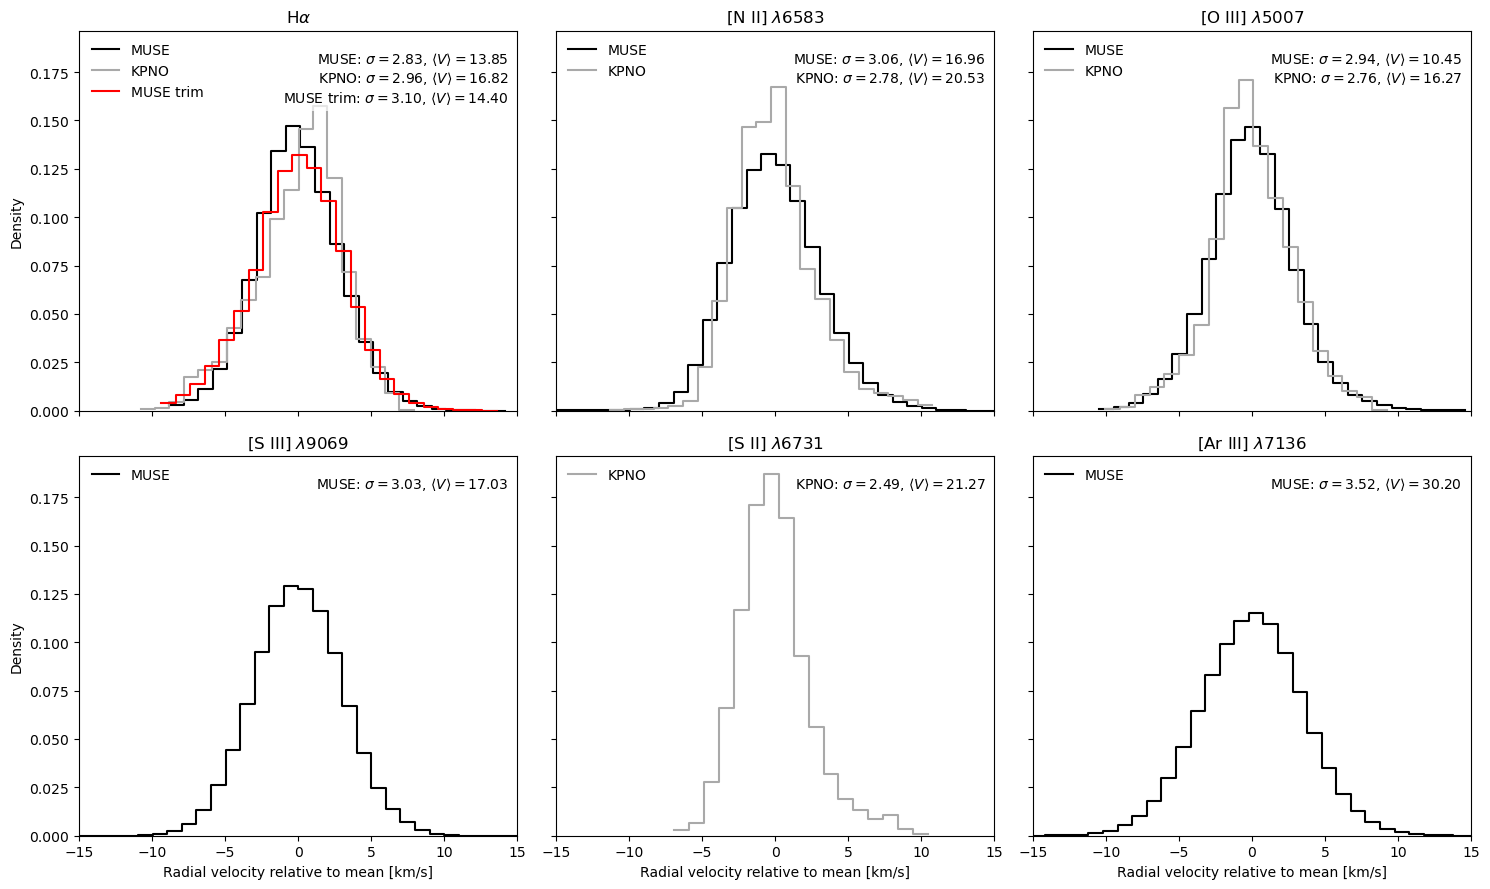

In [9]:
plot_velocity_histograms(
    processed_data,
    line_order=line_order,
    binwidth=1.0,
    xlim=(-15, 15),
    log_scale=False,
    savepath=None,
)

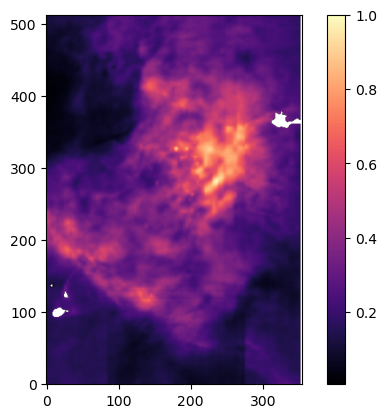

In [24]:
img = plt.imshow(raw_data['Halpha','KPNO']['sb'],
                 origin="lower", cmap="magma")
plt.colorbar(img)
plt.show()

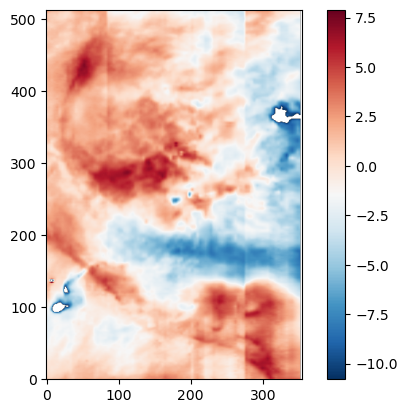

In [10]:
img = plt.imshow(raw_data['Halpha','KPNO']['vv'] - np.nanmean(raw_data['Halpha','KPNO']['vv']),
                 origin="lower", cmap="RdBu_r")
plt.colorbar(img)
plt.show()

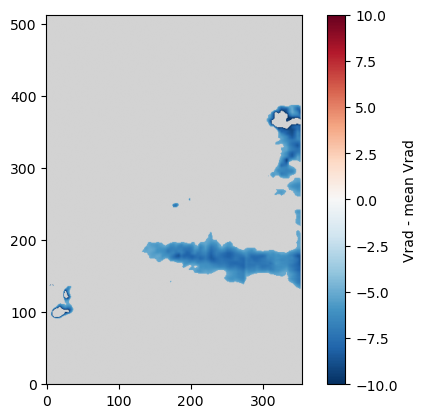

11744
179958
0.06525967170117472


In [11]:
data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= -10) & (data <= -5), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')

plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

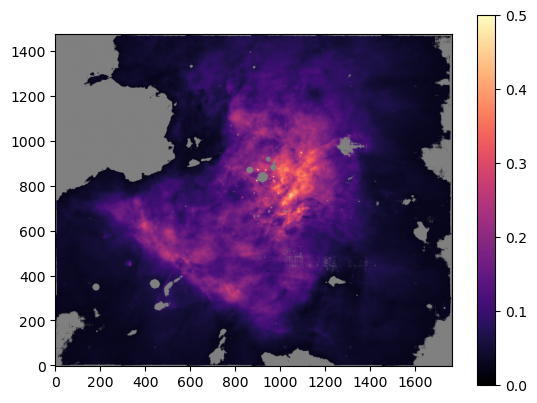

In [28]:
img = plt.imshow(raw_data['Halpha','MUSE']['sb'],
                 origin="lower", cmap="magma",
                vmin = 0,
                vmax = 0.5)
plt.colorbar(img)
img.cmap.set_bad(color='gray')

plt.show()

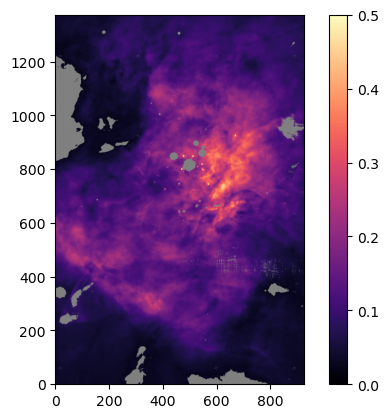

In [29]:
img = plt.imshow(raw_data['Halpha','MUSE trim']['sb'],
                 origin="lower", cmap="magma",
                vmin = 0,
                vmax = 0.5)
plt.colorbar(img)
img.cmap.set_bad(color='gray')

plt.show()

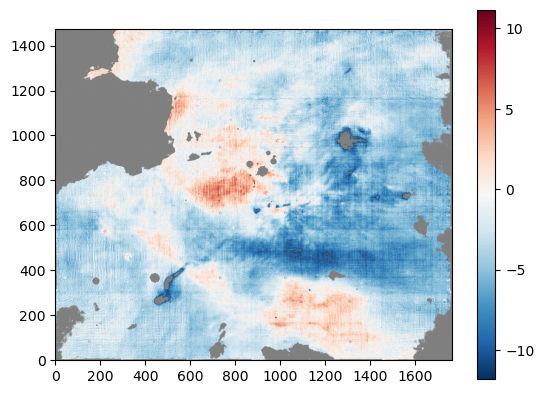

In [12]:
img = plt.imshow(raw_data['Halpha','MUSE']['vv'] - np.nanmean(raw_data['Halpha','KPNO']['vv']),
                 origin="lower", cmap="RdBu_r")
plt.colorbar(img)
img.cmap.set_bad(color='gray')

plt.show()

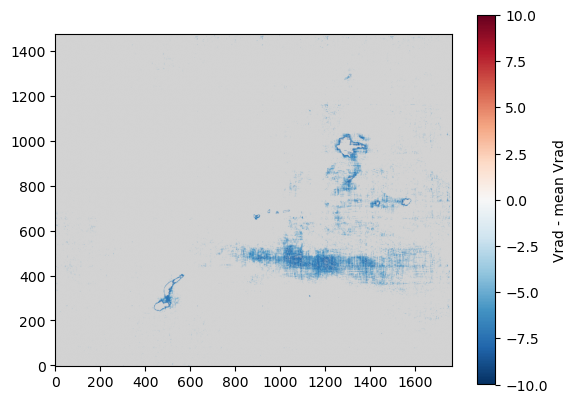

80634
2188334
0.03684720888127681


In [13]:
data = raw_data['Halpha', 'MUSE']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= -10) & (data <= -5), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

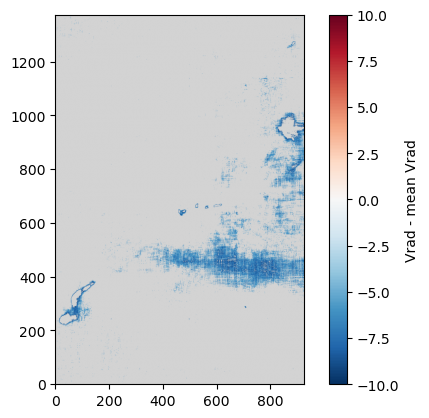

74308
1208837
0.06147065319807385


In [20]:
data = raw_data['Halpha', 'MUSE trim']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= -10) & (data <= -5), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

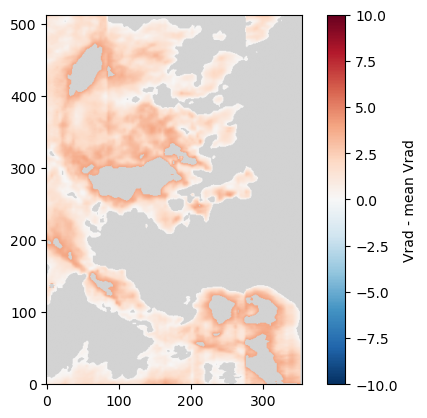

88666
179958
0.49270385312128384


In [14]:
data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 0) & (data <= 3), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')

plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

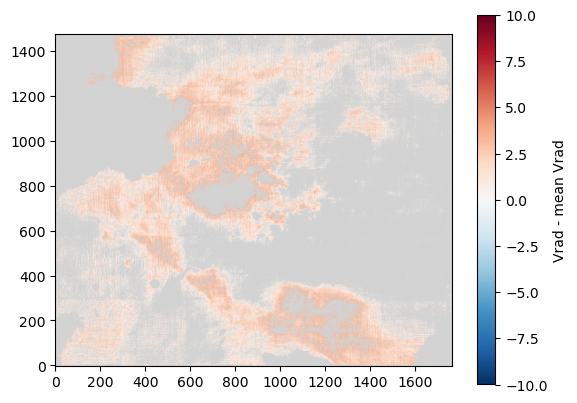

893616
2188334
0.4083544833649708


In [15]:
data = raw_data['Halpha', 'MUSE']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 0) & (data <= 3), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

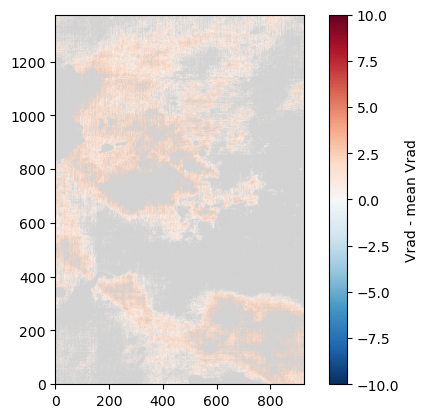

421902
1208837
0.34901479686674053


In [21]:
data = raw_data['Halpha', 'MUSE trim']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 0) & (data <= 3), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

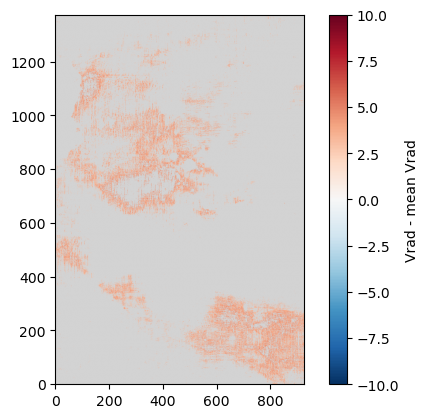

137216
1208837
0.11351075455168894


In [30]:
data = raw_data['Halpha', 'MUSE trim']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 3) & (data <= 5), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

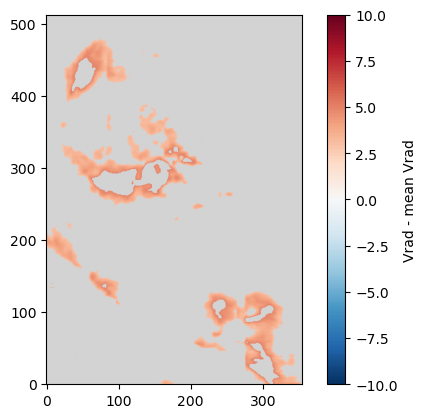

19171
179958
0.10653041265184099


In [31]:
data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 3) & (data <= 5), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='lightgray')
plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

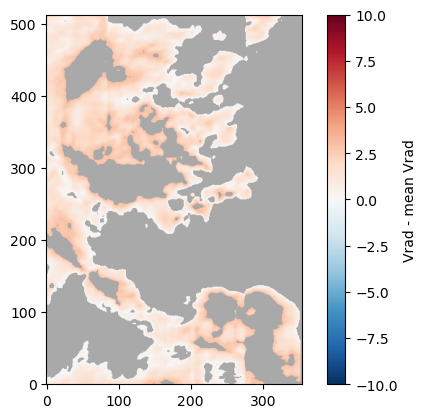

76025
179958
0.4224596850376199


In [18]:
data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 0) & (data <= 3.0), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='darkgray')

plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

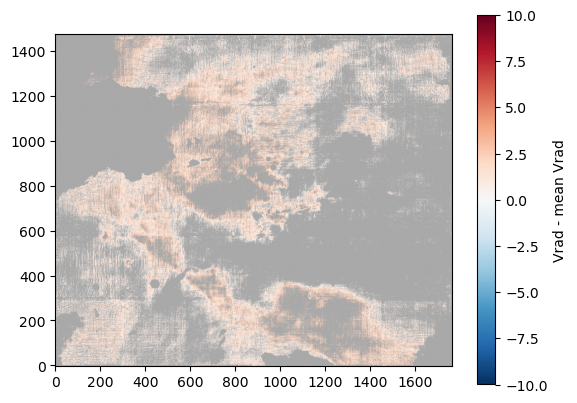

755844
2188334
0.34539700064067


In [19]:
data = raw_data['Halpha', 'MUSE']['vv']
data = data - np.nanmean(data)

filtered_data = np.where((data >= 0) & (data <= 3.0), data, np.nan)

img = plt.imshow(
    filtered_data,
    origin="lower",
    cmap="RdBu_r",
    vmin=-10,
    vmax=+10
)
img.cmap.set_bad(color='darkgray')

plt.colorbar(img, label="Vrad - mean Vrad")
plt.show()

print(np.sum(~np.isnan(filtered_data)))
print(np.sum(~np.isnan(data)))
print(np.sum(~np.isnan(filtered_data))/np.sum(~np.isnan(data)))

# Slices

MUSE Slices

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Original velocity map
data = raw_data['Halpha', 'MUSE']['vv']
data = data - np.nanmean(data)

# Velocity bin setup
dv = 1.0  # km/s
vmin = -10
vmax = 10

edges = np.arange(vmin, vmax + dv, dv)

velocity_slices = []
velocity_labels = []

for v0, v1 in zip(edges[:-1], edges[1:]):

    filtered_data = np.where(
        (data >= v0) & (data < v1),
        data,
        np.nan
    )

    velocity_slices.append(filtered_data)
    velocity_labels.append(f"{v0:.0f} to {v1:.0f} km/s")

# Convert list into 3D cube
velocity_cube = np.array(velocity_slices)

print(velocity_cube.shape)

(20, 1476, 1766)


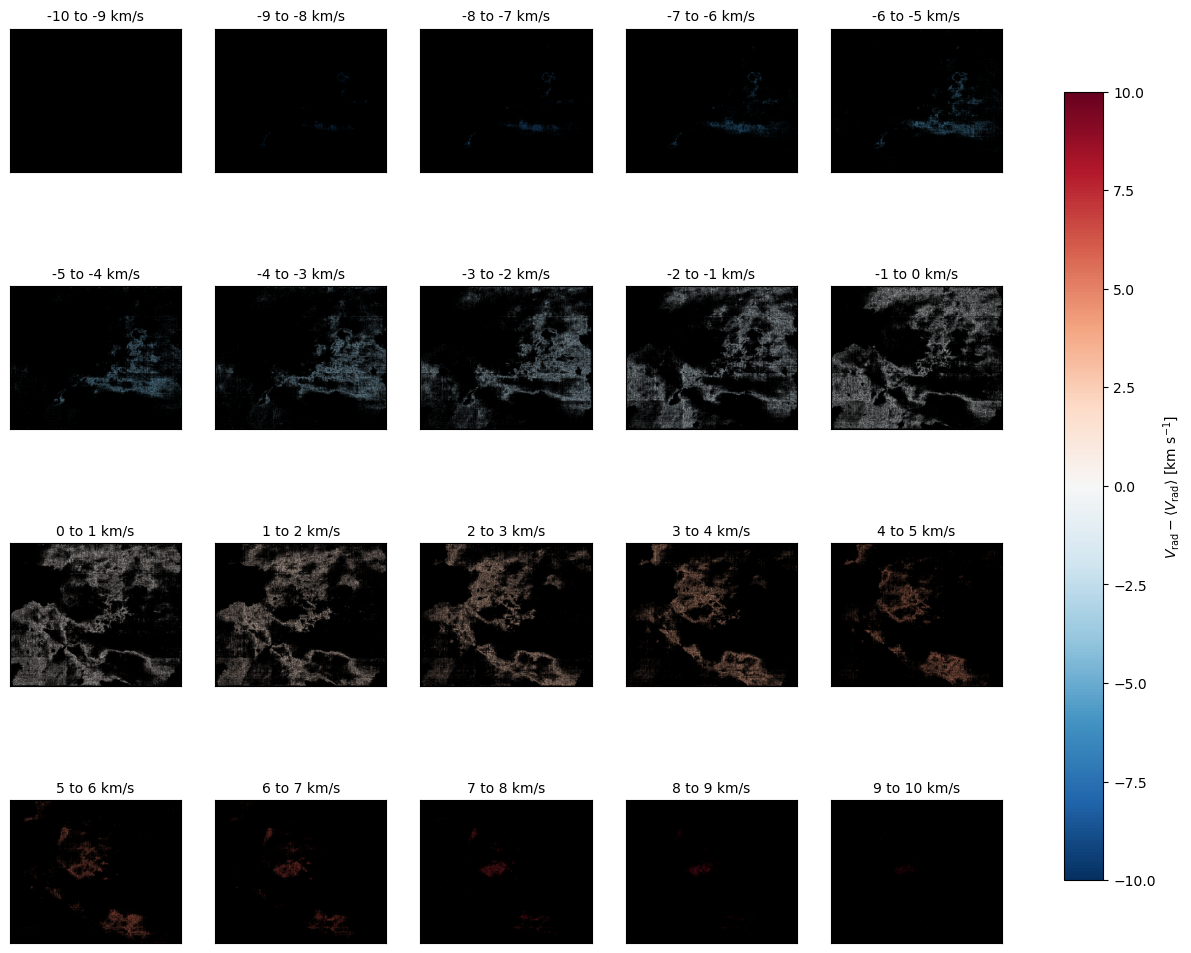

In [47]:
import math

n_slices = velocity_cube.shape[0]

n_cols = 5
n_rows = math.ceil(n_slices / n_cols)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for k, ax in enumerate(axes):

    if k < n_slices:
        img = ax.imshow(
            velocity_cube[k],
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(velocity_labels[k], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    else:
        ax.axis("off")

fig.colorbar(
    img,
    ax=axes,
    shrink=0.8,
    label=r"$V_{\rm rad} - \langle V_{\rm rad} \rangle$ [km s$^{-1}$]"
)

plt.show()

MUSE trim

In [56]:
# Original velocity map
data = raw_data['Halpha', 'MUSE trim']['vv']
data = data - np.nanmean(data)

# Velocity bin setup
dv = 1.0  # km/s
vmin = -10
vmax = 10

edges = np.arange(vmin, vmax + dv, dv)

velocity_slices = []
velocity_labels = []

for v0, v1 in zip(edges[:-1], edges[1:]):

    filtered_data = np.where(
        (data >= v0) & (data < v1),
        data,
        np.nan
    )

    velocity_slices.append(filtered_data)
    velocity_labels.append(f"{v0:.0f} to {v1:.0f} km/s")

# Convert list into 3D cube
velocity_cube = np.array(velocity_slices)

print(velocity_cube.shape)

(20, 1375, 925)


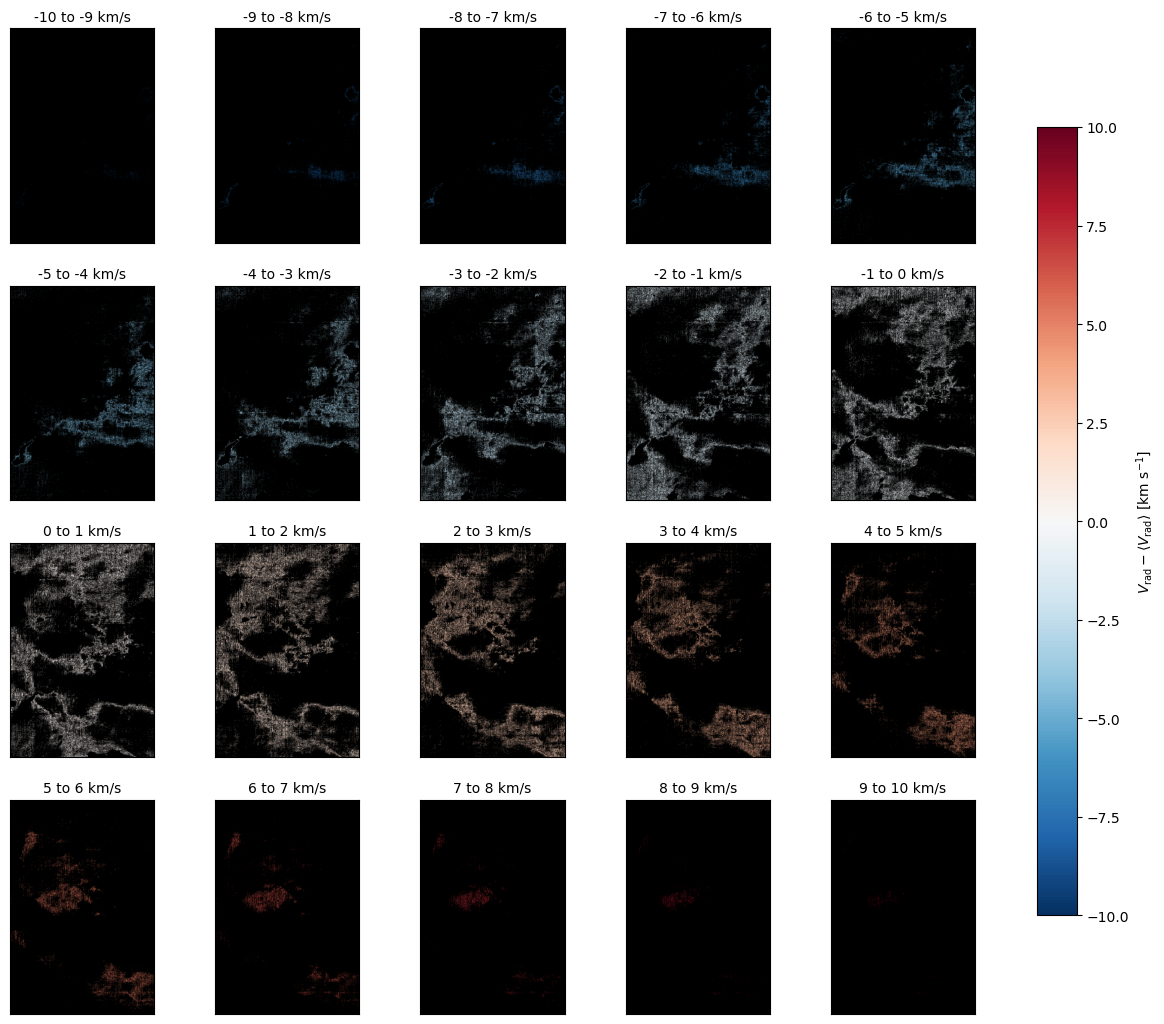

In [60]:
import math

n_slices = velocity_cube.shape[0]

n_cols = 5
n_rows = math.ceil(n_slices / n_cols)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for k, ax in enumerate(axes):

    if k < n_slices:
        img = ax.imshow(
            velocity_cube[k],
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(velocity_labels[k], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    else:
        ax.axis("off")

fig.colorbar(
    img,
    ax=axes,
    shrink=0.8,
    label=r"$V_{\rm rad} - \langle V_{\rm rad} \rangle$ [km s$^{-1}$]"
)

plt.savefig('MUSE trim vel slices', bbox_inches="tight")

plt.show()

KPNO Slices

In [61]:

# Original velocity map
data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

# Velocity bin setup
dv = 1.0  # km/s
vmin = -10
vmax = 10

edges = np.arange(vmin, vmax + dv, dv)

velocity_slices = []
velocity_labels = []

for v0, v1 in zip(edges[:-1], edges[1:]):

    filtered_data = np.where(
        (data >= v0) & (data < v1),
        data,
        np.nan
    )

    velocity_slices.append(filtered_data)
    velocity_labels.append(f"{v0:.0f} to {v1:.0f} km/s")

# Convert list into 3D cube
velocity_cube = np.array(velocity_slices)

print(velocity_cube.shape)

(20, 513, 355)


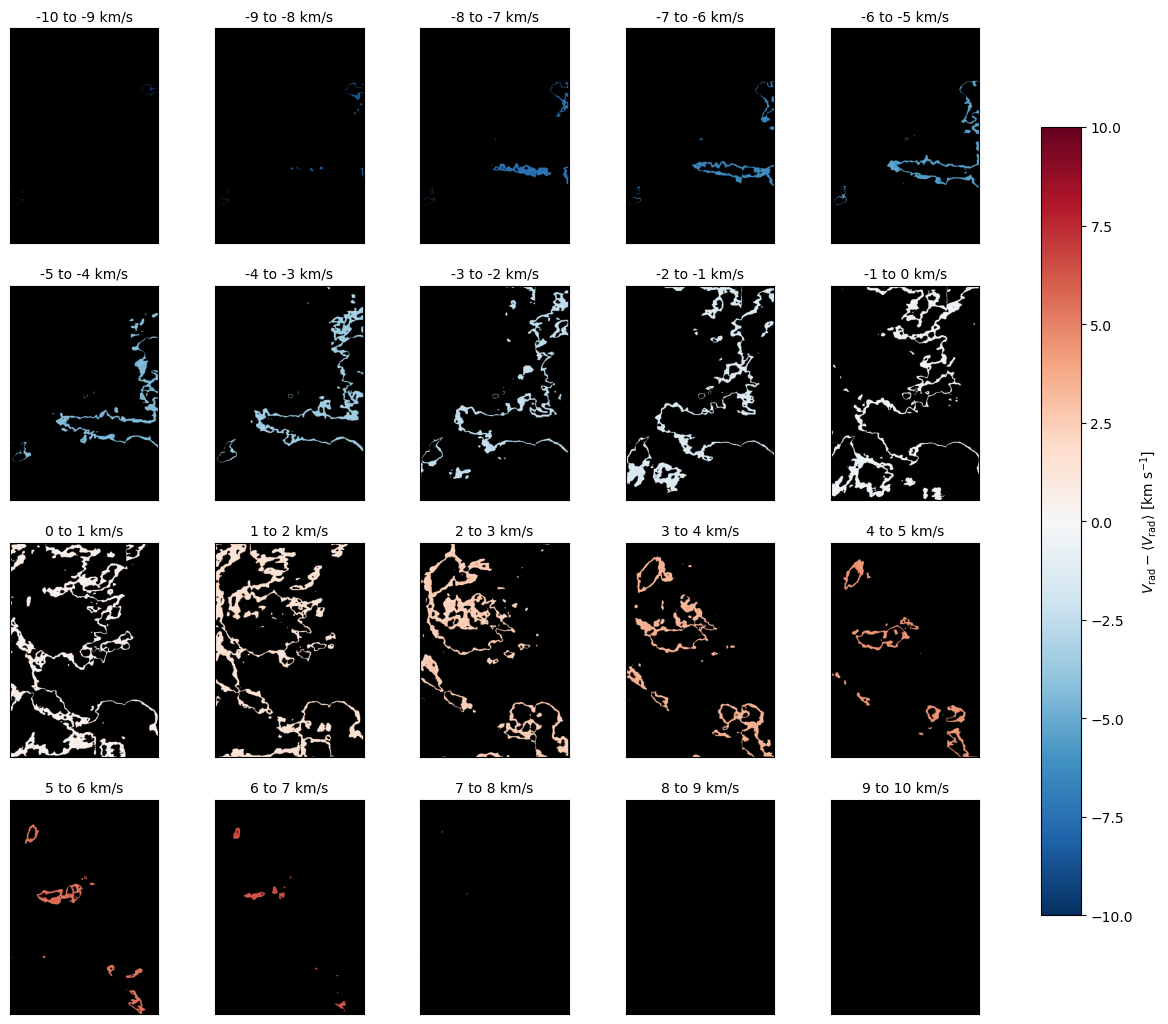

In [62]:
import math

n_slices = velocity_cube.shape[0]

n_cols = 5
n_rows = math.ceil(n_slices / n_cols)

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for k, ax in enumerate(axes):

    if k < n_slices:
        img = ax.imshow(
            velocity_cube[k],
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(velocity_labels[k], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    else:
        ax.axis("off")

fig.colorbar(
    img,
    ax=axes,
    shrink=0.8,
    label=r"$V_{\rm rad} - \langle V_{\rm rad} \rangle$ [km s$^{-1}$]"
)
plt.savefig('KPNO trim vel slices', bbox_inches="tight")

plt.show()

In [63]:
from ipywidgets import interact

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="lightgray")

def show_velocity_slice(k=0):

    plt.figure(figsize=(6, 5))

    img = plt.imshow(
        velocity_cube[k],
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(velocity_labels[k])
    plt.colorbar(img, label=r"$V_{\rm rad} - \langle V_{\rm rad} \rangle$ [km s$^{-1}$]")
    plt.show()

interact(show_velocity_slice, k=(0, velocity_cube.shape[0] - 1));

interactive(children=(IntSlider(value=0, description='k', max=19), Output()), _dom_classes=('widget-interact',…

# Cubes

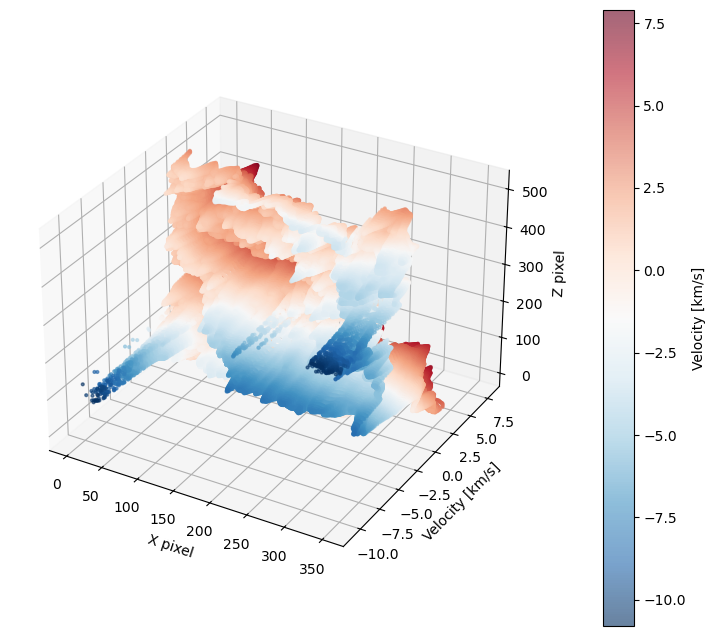

In [54]:
import numpy as np
import matplotlib.pyplot as plt

data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

vmin = np.floor(np.nanmin(data))
vmax = np.ceil(np.nanmax(data))
dv = 1.0

x_all = []
y_all = []
z_all = []
c_all = []

for v0 in np.arange(vmin, vmax, dv):
    v1 = v0 + dv

    mask = np.isfinite(data) & (data >= v0) & (data < v1)
    z_idx, x_idx = np.where(mask)
    vel = data[mask]

    x_all.append(x_idx)
    y_all.append(vel)   # true velocity
    z_all.append(z_idx)
    c_all.append(vel)

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)
z_all = np.concatenate(z_all)
c_all = np.concatenate(c_all)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    x_all,
    y_all,
    z_all,
    c=c_all,
    cmap='RdBu_r',
    s=4,
    alpha=0.6
)

ax.set_xlabel("X pixel")
ax.set_ylabel("Velocity [km/s]")
ax.set_zlabel("Z pixel")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Velocity [km/s]")

plt.show()

In [68]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

mask = np.isfinite(data)

z_idx, x_idx = np.where(mask)
vel = data[mask]

print("Number of points:", len(vel))
print("Velocity range:", np.nanmin(vel), np.nanmax(vel))

fig = go.Figure(data=[
    go.Scatter3d(
        x=x_idx,
        y=vel,
        z=z_idx,
        mode='markers',
        marker=dict(
            size=2,
            color=vel,
            colorscale='RdBu_r',
            opacity=0.7,
            colorbar=dict(title='Velocity [km/s]')
        )
    )
])

fig.update_layout(
    scene=dict(
        xaxis_title='X pixel',
        yaxis_title='Velocity [km/s]',
        zaxis_title='Z pixel'
    ),
    #width=800,
    #height=700
)

fig.show(renderer="browser")

Number of points: 179958
Velocity range: -10.794003604020912 7.898533226881188


In [73]:
import numpy as np
import plotly.graph_objects as go

data = raw_data['Halpha', 'KPNO']['vv']
data = data - np.nanmean(data)

mask = np.isfinite(data)

z_idx, x_idx = np.where(mask)
vel = data[mask]

ny, nx = data.shape
norm = max(nx, ny)

fig = go.Figure(data=[
    go.Scatter3d(
        x=x_idx,
        y=vel,
        z=z_idx,
        mode='markers',
        marker=dict(
            size=2,
            color=vel,
            colorscale='RdBu_r',
            opacity=0.7,
            colorbar=dict(title='Velocity [km/s]')
        )
    )
])

fig.update_layout(
    scene=dict(
        xaxis_title='X pixel',
        yaxis_title='Velocity [km/s]',
        zaxis_title='Z pixel',

        aspectmode='manual',
        aspectratio=dict(
            x=nx / norm,
            y=1.0,      # velocity-axis visual height
            z=ny / norm
        ),

        camera=dict(
            eye=dict(x=2.5, y=2.5, z=2.5)
        )
    ),
    width=1000,
    height=800
)

fig.show(renderer="browser")

In [75]:
import numpy as np
import plotly.graph_objects as go

vv = raw_data['Halpha', 'KPNO']['vv']
vv = vv - np.nanmean(vv)

sb = raw_data['Halpha', 'KPNO']['sb']   # o 'SB' si así está guardado

mask = np.isfinite(vv) & np.isfinite(sb)

z_idx, x_idx = np.where(mask)
vel = vv[mask]
sb_plot = sb[mask]

ny, nx = vv.shape
norm = max(nx, ny)

fig = go.Figure(data=[
    go.Scatter3d(
        x=x_idx,
        y=vel,
        z=z_idx,
        mode='markers',
        marker=dict(
            size=2,
            color=sb_plot,              # <-- ahora el color es SB
            colorscale='magma',       # mejor para brillo que RdBu_r
            opacity=0.7,
            colorbar=dict(title='SB')
        )
    )
])

fig.update_layout(
    scene=dict(
        xaxis_title='X pixel',
        yaxis_title='Velocity [km/s]',
        zaxis_title='Z pixel',
        aspectmode='manual',
        aspectratio=dict(
            x=nx / norm,
            y=1.0,
            z=ny / norm
        ),
        camera=dict(
            eye=dict(x=2.5, y=2.5, z=2.5)
        )
    ),
    width=1000,
    height=800
)

fig.show(renderer="browser")